# __Representing and Manipulating Data Assignment__

## <br>Data Exploration

### <br>__Overview of Each File__

In [4]:
#First importing the necessary tools to make data manipulation possible
#Also importing os to make file navigation simpler

import pandas as pd
import numpy as np
import json
import os

<br>

#### <br>__Reading the Files__

##### Product csv

In [8]:
#Assigning the data in the  to the variable products_data
#loading the file with pandas using pd.read_csv
#index_col = 0 assigns the first row of the data as an index

products_csv_file = ("Documents/UniversityWork/products.csv")
products_data = pd.read_csv(products_csv_file, index_col = 0)

In [9]:
#Display allows us to view the data in various ways, in this code .head allows viewing of the first 5 rows

display(products_data.head())

,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125


- From this display output, we can see that the data shows the __unique ID__ of products (used to identify each product in other datasets), The __SKU__ number of products (a number that retailers assign to products to keep track of stock), the __name__ of the products, the __description__ of the products, the __price__ of the product, and the __average review score__ of products


<br>

##### Users csv

In [13]:
#same steps as previous file
users_csv_file = ("Documents/UniversityWork/users.csv")
users_data = pd.read_csv(users_csv_file)

display(users_data.head())

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


- From this display output, we can see that the data shows __Usernames__, __Date of Birth__, and __States__

<br>

##### Reviews csv

In [17]:
#same steps taken as previous files except this time when stoping the coding line at index_col = 0) there is an error
#this time, I tell pandas to use the python engine "engine = 'python'" instead of the pandas engine, this is because the pandas engine is strict with formatting causing the error
#For the purpose of being able to display the information in the data, we skip bad lines so that the data can be read

reviews_csv_file = ("Documents/UniversityWork/reviews.csv")
reviews_data = pd.read_csv(reviews_csv_file)

display(reviews_data.head())

,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...


##### From this display output, we can see that the data shows __Unique IDs__, __Usernames__, __Scores__, and __Reviews__

<br>

##### Products json

In [21]:
products_json_file = ("Documents/UniversityWork/jcpenney_products.json")

json_products_data = []

with open(products_json_file) as file:
    for every_line in file:
        try:
            json_products_data.append(json.loads(every_line))
        except json.JSONDecodeError as error:
            print(f"error at {line}")

In [22]:
#using the type function we can see that the json file is a dictionary containing information such as sku and list price
print(type(json_products_data))

<class 'list'>


<br>

##### Reviewers json

In [25]:
reviewers_json_file = ("Documents/UniversityWork/jcpenney_reviewers.json")

json_reviewers_data = []

with open(reviewers_json_file) as file:
    for every_line in file:
        try:
            json_reviewers_data.append(json.loads(every_line))
        except json.JSONDecodeError as error:
            print(f"error at {line}")

In [26]:
#As the previous file, we can see that the json file is a disctionary containing information such as username, date of birth, state, and item reviewed
print(type(json_reviewers_data))

<class 'list'>


<br>

### <br>__Data Cleaning__

<br>

#### __Products.csv Data__

<br>

- Converting index name to lower case and column names to lower case

In [33]:
# Convert index name to lower case and remove potential white spaces
products_data.index.name = products_data.index.name.strip().lower()

# Convert column names to lower case and remove potential white spaces
products_data.columns = products_data.columns.str.strip().str.lower()

# Check changes
display(products_data)

,sku,name,description,price,av_score
uniq_id,,,,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125
...,...,...,...,...,...
16e3ca6b6a2d3f5da9a81df6cfe7e27a,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,3.875
209bec04d9f194616358a77d7b41b314,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,3.250
7a8a7cba7b69b4c46ceac1d9666d84f0,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,2.500


<br>

- Converting price and avergae score to float instead of an object for future analysis

In [36]:
# Convert price and av_score to float instead of object
products_data["price"] = pd.to_numeric(products_data["price"])
products_data["av_score"] = pd.to_numeric(products_data["av_score"])

<br>

<br>

##### Errors in the Data

- Missing Data

In [41]:
print(products_data.isnull().sum())

sku              67
name              0
description     543
price          2166
av_score          0
dtype: int64


- From this output we can see missing values in the rows sku, description, price, and average score
- These missing values are likely in the json products data

<br>

- Decriptive Statisitcs

In [45]:
#We use 'describe()' to look at the descriptive statistics of the data, specifically the Price column
print("Product price descriptive statistics:")
print(products_data['price'].describe())

Product price descriptive statistics:
count     5816.000000
mean       144.776618
std        499.223719
min        -65.270000
25%         40.700000
50%         58.010000
75%         87.020000
max      17122.170000
Name: price, dtype: float64


- Potential errors have been found in the data
- There appears to be a negative price(s) in the data __however__, this may be due to refunds
- We will explore this later by looking at reviews

<br>

- Checking if there are any duplicates in Uniq_id in the products.csv data

In [49]:
#Because these products have a unique ID there should be no duplicates in this data
#To check for this I made a variable called duplicate_index_products to see if there were any duplicates

duplicate_index_products = products_data.index.duplicated()
print(products_data[duplicate_index_products])

Empty DataFrame
Columns: [sku, name, description, price, av_score]
Index: []


- As you can see from the output 'Empty DataFrame' there were no duplicate Uniq_id values

<br>

#### __Products.json Data__

<br>

- Making the json data a DataFrame

In [55]:
# Using 'DataFrame' converts the json data into a DataFrame
json_products_data = pd.DataFrame(json_products_data)


# Convert column names to lower case and remove potential white spaces
json_products_data.columns = json_products_data.columns.str.strip().str.lower()


# Checking changes
display(json_products_data)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7977,16e3ca6b6a2d3f5da9a81df6cfe7e27a,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,view all brands,jcpenney|for-the-home|view all brands,3.875,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'cced4433', 'Review': '1) the hose i...","[30611c465e893326b8b676ccc5e9e42b, 799d6290601..."
7978,209bec04d9f194616358a77d7b41b314,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,sale,jcpenney|for-the-home|sale,3.250,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'rtbj4421', 'Review': '1) the hose i...","[ac4dcfeca034e705ac2be1a79bbe3acf, c2300c3e551..."
7979,7a8a7cba7b69b4c46ceac1d9666d84f0,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,vacuums & floorcare,jcpenney|for-the-home|vacuums & floorcare,2.500,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'qven4314', 'Review': '1) the hose i...","[fc831da1b1d09b0bd7d6893e9615232f, 9f5f2c625d4..."
7980,9887bb20c12be3c09d094e97ac8d22be,pp5005921226,Hope Chest Embroidered Quilt & Accessories,,,35.63142,comforters & bedding sets,jcpenney|bed-bath|comforters & bedding sets,3.500,http://www.jcpenney.com/hope-chest-embroidered...,http://s7d9.scene7.com/is/image/JCPenney/DP072...,Asstd National Brand,8,"[{'User': 'sguz3424', 'Review': 'This product ...","[9968d41d84274b22610278d352f0753a

- We can see missing rows here, this will be adressed

In [57]:
print(json_products_data.isnull().sum())

uniq_id                   0
sku                       0
name_title                0
description               0
list_price                0
sale_price                0
category                  0
category_tree             0
average_product_rating    0
product_url               0
product_image_urls        0
brand                     0
total_number_reviews      0
reviews                   0
bought with               0
dtype: int64


- These are currently not showing up as NaN values

<br>

<br>

- Renaming the json DataFrame column titles to match products_data 

In [62]:
# Using 'rename' to change column names
json_products_data.rename(columns = {'list_price': 'price', 'name_title': 'name'}, inplace = True)

# Checking changes
print(json_products_data.columns)

Index(['uniq_id', 'sku', 'name', 'description', 'price', 'sale_price',
       'category', 'category_tree', 'average_product_rating', 'product_url',
       'product_image_urls', 'brand', 'total_number_reviews', 'reviews',
       'bought with'],
      dtype='object')


<br>

- Checking data info

In [65]:
# Checking data info
print(json_products_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniq_id                 7982 non-null   object 
 1   sku                     7982 non-null   object 
 2   name                    7982 non-null   object 
 3   description             7982 non-null   object 
 4   price                   7982 non-null   object 
 5   sale_price              7982 non-null   object 
 6   category                7982 non-null   object 
 7   category_tree           7982 non-null   object 
 8   average_product_rating  7982 non-null   float64
 9   product_url             7982 non-null   object 
 10  product_image_urls      7982 non-null   object 
 11  brand                   7982 non-null   object 
 12  total_number_reviews    7982 non-null   int64  
 13  reviews                 7982 non-null   object 
 14  bought with             7982 non-null   

<br>

- Changing numeric values to float

In [68]:
# Changing 'list_price' to float
json_products_data['price'] = pd.to_numeric(json_products_data["price"])

# Changing 'price' to float, invalid prices become NaN (there was invalid prices without the coerce)
json_products_data['sale_price'] = pd.to_numeric(json_products_data["sale_price"], errors='coerce')

# Checking changes
print(json_products_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniq_id                 7982 non-null   object 
 1   sku                     7982 non-null   object 
 2   name                    7982 non-null   object 
 3   description             7982 non-null   object 
 4   price                   5816 non-null   float64
 5   sale_price              7719 non-null   float64
 6   category                7982 non-null   object 
 7   category_tree           7982 non-null   object 
 8   average_product_rating  7982 non-null   float64
 9   product_url             7982 non-null   object 
 10  product_image_urls      7982 non-null   object 
 11  brand                   7982 non-null   object 
 12  total_number_reviews    7982 non-null   int64  
 13  reviews                 7982 non-null   object 
 14  bought with             7982 non-null   

<br>

- Checking missing values

In [71]:
print(json_products_data.isnull().sum())

uniq_id                      0
sku                          0
name                         0
description                  0
price                     2166
sale_price                 263
category                     0
category_tree                0
average_product_rating       0
product_url                  0
product_image_urls           0
brand                        0
total_number_reviews         0
reviews                      0
bought with                  0
dtype: int64


- Because I changed the values to floats instead of objects, some of these prices have become invalid due to incorrect formating or blank rows

<br>

- Making uniq_id index

In [75]:
# Making 'uniq_id' the index to match product_data DataFrame
json_products_data.set_index('uniq_id', inplace=True)

display(json_products_data)

,sku,name,description,price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16e3ca6b6a2d3f5da9a81df6cfe7e27a,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,view all brands,jcpenney|for-the-home|view all brands,3.875,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'cced4433', 'Review': '1) the hose i...","[30611c465e893326b8b676ccc5e9e42b, 799d6290601..."
209bec04d9f194616358a77d7b41b314,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,sale,jcpenney|for-the-home|sale,3.250,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'rtbj4421', 'Review': '1) the hose i...","[ac4dcfeca034e705ac2be1a79bbe3acf, c2300c3e551..."
7a8a7cba7b69b4c46ceac1d9666d84f0,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,vacuums & floorcare,jcpenney|for-the-home|vacuums & floorcare,2.500,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'qven4314', 'Review': '1) the hose i...","[fc831da1b1d09b0bd7d6893e9615232f, 9f5f2c625d4..."


<br>

- Finding Valid Prices by sku

In [78]:
# Using groupby to find valid prices by sku for the missing price values
sku_price = (json_products_data.groupby("sku")["price"] .apply(lambda x: x.dropna().unique()) .to_dict())

In [79]:
# Checking price in row is NaN
def replace_invalid_price(row):
    if pd.isna(row['price']):  # Looks up valid price for row
        valid_prices = sku_price.get(row['sku'], []) # gets valid price for sku
        if len(valid_prices) > 0: # checks if sku had valid price
            return valid_prices[0] # replaces valid price with NaN if valid price exists
    return row['price'] # returns row with now valid price

In [80]:
# applies the previous line of code to each row in dataframe
json_products_data['price'] = json_products_data.apply(replace_invalid_price, axis=1)

display(json_products_data)

,sku,name,description,price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16000,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16e3ca6b6a2d3f5da9a81df6cfe7e27a,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,view all brands,jcpenney|for-the-home|view all brands,3.875,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'cced4433', 'Review': '1) the hose i...","[30611c465e893326b8b676ccc5e9e42b, 799d6290601..."
209bec04d9f194616358a77d7b41b314,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,sale,jcpenney|for-the-home|sale,3.250,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'rtbj4421', 'Review': '1) the hose i...","[ac4dcfeca034e705ac2be1a79bbe3acf, c2300c3e551..."
7a8a7cba7b69b4c46ceac1d9666d84f0,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67000,vacuums & floorcare,jcpenney|for-the-home|vacuums & floorcare,2.500,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'qven4314', 'Review': '1) the hose i...","[fc831da1b1d09b0bd7d6893e9615232f, 9f5f2c625d4..."


<br>

- This fixed some of the missing prices which is observed when checking the missing data

In [83]:
print(json_products_data.isnull().sum())

sku                          0
name                         0
description                  0
price                     1888
sale_price                 263
category                     0
category_tree                0
average_product_rating       0
product_url                  0
product_image_urls           0
brand                        0
total_number_reviews         0
reviews                      0
bought with                  0
dtype: int64


<br>

<br>

#### __Reviews.csv Data__

<br>

- Checking data info

In [89]:
print(reviews_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39063 entries, 0 to 39062
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Uniq_id   39063 non-null  object
 1   Username  39063 non-null  object
 2   Score     39063 non-null  int64 
 3   Review    39063 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB
None


<br>

- Descriptive Statistics

In [92]:
#We use 'describe()' to look at the descriptive statistics of the data, specifically the Price column
print("Reviews score descriptive statistics:")
print(reviews_data['Score'].describe())

Reviews score descriptive statistics:
count    39063.000000
mean         1.487648
std          1.400332
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: Score, dtype: float64


- There does not appear to be any errors such as negative review scores
- Interestingly, the average score is quite low but I will explore this later

<br>

- Checking for missing values

In [96]:
print(reviews_data.isnull().sum())

Uniq_id     0
Username    0
Score       0
Review      0
dtype: int64


- There are no missing values

<br>

- Converting column names to lower case and removeing potential white spaces

In [100]:
# Convert column names to lower case and remove potential white spaces
reviews_data.columns = reviews_data.columns.str.strip().str.lower()

# Check changes
display(reviews_data)

,uniq_id,username,score,review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...
...,...,...,...,...
39058,2cc49292b44cc12fe22206440d3e7472,whxp1433,2,This bedspread is as practical as it is beauti...
39059,2cc49292b44cc12fe22206440d3e7472,kfqi4333,1,I purchased this same wedding ring quilt 16 ye...
39060,2cc49292b44cc12fe22206440d3e7472,bynj4221,0,This was a gift for my daughter and she loves ...
39061,2cc49292b44cc12fe22206440d3e7472,eawq2222,1,I purchased these pillow shams as well as the ...


<br>

- Checking if there are any duplicate reviews

In [103]:
# Checking if there are any duplicate rows
duplicate_review_rows = reviews_data[reviews_data.duplicated()]

print(duplicate_review_rows)

Empty DataFrame
Columns: [uniq_id, username, score, review]
Index: []


- There are no duplicate rows

<br>

#### __Reviews.json Data__

<br> 

- Making the data a DataFrame

In [109]:
# Using 'DataFrame' converts the json data into a DataFrame

json_reviewers_data = pd.DataFrame(json_reviewers_data)


# Convert column names to lower case and remove potential white spaces
json_reviewers_data.columns = json_reviewers_data.columns.str.strip().str.lower()


# Checking changes
display(json_reviewers_data)

,username,dob,state,reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."
4,jjbd1412,26.07.2001,Georgia,[]
...,...,...,...,...
4995,mfnn1212,27.07.1997,Delaware,[d6cd506246bd17afa611b6a06236713c]
4996,ejnb3414,01.08.1976,Minnesota,[97de1506cd0bcbe50f2797cd0588eb81]
4997,pdzw1433,28.07.1994,Ohio,"[799d62906019d910fa744987da184ae7, b8f5deb7b02..."
4998,npha1342,07.08.1953,Montana,[6250b1d691cd3842f05b87736f2fadbf]


<br>

In [111]:
print(json_reviewers_data.isnull().sum())

username    0
dob         0
state       0
reviewed    0
dtype: int64


- The output tells us theres no null values, but we can see from the above display that there are missing reviewed products

- This will be addressed later

<br>

- Checking if the Date of Birth column containes valid dob

In [116]:
# Convert the dob column to datetime
try:
    json_reviewers_data['dob'] = pd.to_datetime(json_reviewers_data['dob'], format='%d.%m.%Y', errors='coerce')
except Exception as e:
    print(f"Error parsing dates: {e}")

# Check for invalid dates 
invalid_dobs = json_reviewers_data[json_reviewers_data['dob'].isna()]

if not invalid_dobs.empty:
    print("Invalid DOB entries:")
    print(invalid_dobs)
else:
    print("All DOB entries are valid.")

All DOB entries are valid.


- There are no invalid date of births

<br>

#### __Users.csv Data__

<br>

- Checking data info

In [122]:
print(users_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB
None


<br>

- Descriptive Statistics

In [125]:
print(users_data.describe())

        Username         DOB          State
count       5000        5000           5000
unique      4999          52             57
top     dqft3311  07.08.1953  Massachusetts
freq           2         112            107


<br>

- Checking for missing values

In [128]:
print(users_data.isnull().sum())

Username    0
DOB         0
State       0
dtype: int64


- There are no missing values

<br>

- Making the columns lower case and removing any white spaces

In [132]:
# Convert column names to lower case and remove potential white spaces
users_data.columns = users_data.columns.str.strip().str.lower()

# Check changes
display(users_data)

,username,dob,state
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia
...,...,...,...
4995,mfnn1212,27.07.1997,Delaware
4996,ejnb3414,01.08.1976,Minnesota
4997,pdzw1433,28.07.1994,Ohio
4998,npha1342,07.08.1953,Montana


<br>

- Checking if there is any duplicate user information

In [135]:
#Because users have a uniq username, there should be no duplicates
#To check for this I made a variable called duplicate_index_users to see if there were any duplicates

duplicate_index_users = users_data.index.duplicated().sum()
print(duplicate_index_users)

0


- There is one duplicate username

In [137]:
# Check for duplicates, if duplicate is found it keeps the first one found
remove_duplicate_user = users_data[~users_data.index.duplicated(keep='first')]

# Checks if any duplicates are remaining
duplicate_users_remaining = remove_duplicate_user.index.duplicated().sum()
print(duplicate_users_remaining)

0


- There is now no duplicates

<br>

- Checking if date of births are valid

In [141]:
# Convert the dob column to datetime
try:
    users_data['dob'] = pd.to_datetime(users_data['dob'], format='%d.%m.%Y', errors='coerce')
except Exception as e:
    print(f"Error parsing dates: {e}")

# Check for invalid dates 
invalid_dobs_users = users_data[users_data['dob'].isna()]

if not invalid_dobs_users.empty:
    print("Invalid DOB entries:")
    print(invalid_dobs_users)
else:
    print("All DOB entries are valid.")

All DOB entries are valid.


- There are no invalid date of births

<br>

### __Merging Files__

<br>

#### Products csv and Products json

In [147]:
# Using merge to combine the csv and json data frames
merged_products = pd.merge(products_data, json_products_data, left_index = True, right_index = True, how = 'outer')

display(merged_products)

,sku_x,name_x,description_x,price_x,av_score,sku_y,name_y,description_y,price_y,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,,,,,,
000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. Johns Bay have that classic...,53.18,2.750000,pp5006650503,St. John's Bay® Wide Leg Linen Pants,Our pants from St. John's Bay have that classi...,53.18,30.20,,,2.750000,http://www.jcpenney.com/st-johns-bay-wide-leg-...,http://s7d9.scene7.com/is/image/JCPenney/DP021...,St. John's Bay,8,"[{'User': 'zzku2121', 'Review': 'Discovered th...","[9d9f3cfc76619b167d35fb8e13fea87b, 0abc85a1a28..."
000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,70.97,loafers,jcpenney|loafers,3.000000,http://www.jcpenney.com/east-5th-elanor-slip-o...,http://s7d2.scene7.com/is/image/JCPenney/DP110...,East Fifth,1,"[{'User': 'zfee4232', 'Review': 'Perfect. .. ....","[66fba1d299a5b4e5f4717d97e857f2bc, 587fa3bfcae..."
000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,84.59,all dress shoes,jcpenney|shoes|all dress shoes,2.222222,http://www.jcpenney.com/stafford-gunner-mens-c...,http://s7d9.scene7.com/is/image/JCPenney/DP090...,STAFFORD,9,"[{'User': 'lxlv2432', 'Review': 'Simple elegan...","[8fbe9d0a4323d28eaa572f75794b8754, a85cd8fc88f..."
001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,64.57,slow cookers & warmers,jcpenney|gift-registry|slow cookers & warmers,2.666667,http://www.jcpenney.com/crock-pot-6-qt-cook-ca...,http://s7d9.scene7.com/is/image/JCPenney/DP061...,CROCK-POT,3,"[{'User': 'yssd3343', 'Review': 'The descripti...","[785f1c28b43ad343330caf024ff3a738, 616ed072801..."
0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,53.17,clothing sets,jcpenney|clothing sets,3.750000,http://www.jcpenney.com/keepsake-christening-s...,http://s7d2.scene7.com/is/image/JCPenney/DP071...,KEEPSAKE,4,"[{'User': 'igjb2313', 'Review': 'My mom bought...","[9d6ddae3c28d8ac01f0aae2064e0720a, af0a88c77ef..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcb9d8bcae951a1a9bfd701824fb40c,pp5006292066,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,2.666667,pp5006292066,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,27.93,suits & separates,jcpenney|women|suits & separates,2.666667,http://www.jcpenney.com/liz-claiborne-emma-cre...,http://s7d9.scene7.com/is/image/JCPenney/DP112...,LIZ CLAIBORNE,3,"[{'User': 'cqzv1144', 'Review': 'Although ankl...","[43d1651381d17cb7fce9f2b0f620ad20, ea91d3d3ca0..."
ffd0291168a5aae78274bb933278b960,pp5004020718,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,3.400000,pp5004020718,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,14.19,french toast,jcpenney|french toast,3.400000,http://www.jcpenney.com/french-toast-trimmed-f...,http://s7d2.scene7.com/is/image/JCPenney/DP092...,French Toast,5,"[{'User': 'fkhu2323', 'Review': 'I purchas

- There are now 'duplicate' columns such as sku_x and sku_y because both of these dataframes had those columns
- I now have to check if the columns match before combining or removing them

<br>

In [150]:
# Creates new dataframe which only contains mismatched rows of sku
sku_mismatched = merged_products[merged_products['sku_x'] != merged_products['sku_y']]

In [151]:
# Checks if sku mismatch is an empty value 
if not sku_mismatched.empty:
    print(f"mismatched rows found: {len(sku_mismatched)}") 
    print(sku_mismatched) # if mismatched row is found prints its information
else:
    display("All rows match between sku_x and sku_y") # if not mismatched rows are found this prints

mismatched rows found: 69
                                 sku_x  \
uniq_id                                  
0563348ce32c1a86bd897690ccb672d4   NaN   
08daf20a62b797053019a926687abb53   NaN   
121fd2f8102c2fc4dc1fb0634dfd6fea   NaN   
16ccbb55e35d59d7e3bdeb571013ef4c   NaN   
1edc6b476b180bf9c40e9390a874ba6a   NaN   
...                                ...   
f4ae254c25f1a3191b23cee6ac9a396d   NaN   
f83b1fed1ede51ebfb3e915cc2a3962d   NaN   
f98a0de072d044405bb87f17238462f4   NaN   
fc213145168faa94bae198f173d27796   NaN   
fc6a4836c97bdd34364bbeaafad93858   NaN   

                                                                             name_x  \
uniq_id                                                                               
0563348ce32c1a86bd897690ccb672d4                       Ruffle Power Bath Collection   
08daf20a62b797053019a926687abb53             O/X-Back Set of 3 Adjustable Barstools   
121fd2f8102c2fc4dc1fb0634dfd6fea                        Melissa & Doug® Panda P

- You can see from the output that there are 69 mismatched sku rows

<br>

In [154]:
# Checking where sku_x can be applied to sku_y
sku_x_to_y = merged_products['sku_y'].isna() & merged_products['sku_x'].notna()
print('sku_x can be applied to sku_y: \n', merged_products[sku_x_to_y])

sku_x can be applied to sku_y: 
 Empty DataFrame
Columns: [sku_x, name_x, description_x, price_x, av_score, sku_y, name_y, description_y, price_y, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, reviews, bought with]
Index: []


- No skus can be applied from sku_x to sku_y

<br>

In [157]:
# Checking where sku_y can be applied to sku_x
sku_y_to_x = merged_products['sku_x'].isna() & merged_products['sku_y'].notna()
print('sku_y can be applied to sku_x: \n', merged_products[sku_y_to_x])

sku_y can be applied to sku_x: 
                                  sku_x  \
uniq_id                                  
0563348ce32c1a86bd897690ccb672d4   NaN   
08daf20a62b797053019a926687abb53   NaN   
121fd2f8102c2fc4dc1fb0634dfd6fea   NaN   
16ccbb55e35d59d7e3bdeb571013ef4c   NaN   
1edc6b476b180bf9c40e9390a874ba6a   NaN   
...                                ...   
f4ae254c25f1a3191b23cee6ac9a396d   NaN   
f83b1fed1ede51ebfb3e915cc2a3962d   NaN   
f98a0de072d044405bb87f17238462f4   NaN   
fc213145168faa94bae198f173d27796   NaN   
fc6a4836c97bdd34364bbeaafad93858   NaN   

                                                                             name_x  \
uniq_id                                                                               
0563348ce32c1a86bd897690ccb672d4                       Ruffle Power Bath Collection   
08daf20a62b797053019a926687abb53             O/X-Back Set of 3 Adjustable Barstools   
121fd2f8102c2fc4dc1fb0634dfd6fea                        Melissa & Doug® 

- 67 sku values can be applied from sku_y to sku_x

<br>

In [160]:
# Combing sku_y with sku_x
merged_products['sku'] = merged_products['sku_y'].combine_first(merged_products['sku_x'])

# Removing the sku_x and sku_y columns leaving only the sku column
merged_products = merged_products.drop(columns=['sku_x', 'sku_y'])

# Reordering columns so sku is in its original position not the end of the column
sku_columns = list(merged_products.columns)
sku_index = sku_columns.index('sku') # Finds current location of sku
sku_columns.insert(0, sku_columns.pop(sku_index)) # Moves sku to first column
merged_products = merged_products[sku_columns]

display(merged_products)

,sku,name_x,description_x,price_x,av_score,name_y,description_y,price_y,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,,,,,
000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. Johns Bay have that classic...,53.18,2.750000,St. John's Bay® Wide Leg Linen Pants,Our pants from St. John's Bay have that classi...,53.18,30.20,,,2.750000,http://www.jcpenney.com/st-johns-bay-wide-leg-...,http://s7d9.scene7.com/is/image/JCPenney/DP021...,St. John's Bay,8,"[{'User': 'zzku2121', 'Review': 'Discovered th...","[9d9f3cfc76619b167d35fb8e13fea87b, 0abc85a1a28..."
000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,70.97,loafers,jcpenney|loafers,3.000000,http://www.jcpenney.com/east-5th-elanor-slip-o...,http://s7d2.scene7.com/is/image/JCPenney/DP110...,East Fifth,1,"[{'User': 'zfee4232', 'Review': 'Perfect. .. ....","[66fba1d299a5b4e5f4717d97e857f2bc, 587fa3bfcae..."
000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,84.59,all dress shoes,jcpenney|shoes|all dress shoes,2.222222,http://www.jcpenney.com/stafford-gunner-mens-c...,http://s7d9.scene7.com/is/image/JCPenney/DP090...,STAFFORD,9,"[{'User': 'lxlv2432', 'Review': 'Simple elegan...","[8fbe9d0a4323d28eaa572f75794b8754, a85cd8fc88f..."
001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,64.57,slow cookers & warmers,jcpenney|gift-registry|slow cookers & warmers,2.666667,http://www.jcpenney.com/crock-pot-6-qt-cook-ca...,http://s7d9.scene7.com/is/image/JCPenney/DP061...,CROCK-POT,3,"[{'User': 'yssd3343', 'Review': 'The descripti...","[785f1c28b43ad343330caf024ff3a738, 616ed072801..."
0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,53.17,clothing sets,jcpenney|clothing sets,3.750000,http://www.jcpenney.com/keepsake-christening-s...,http://s7d2.scene7.com/is/image/JCPenney/DP071...,KEEPSAKE,4,"[{'User': 'igjb2313', 'Review': 'My mom bought...","[9d6ddae3c28d8ac01f0aae2064e0720a, af0a88c77ef..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcb9d8bcae951a1a9bfd701824fb40c,pp5006292066,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,2.666667,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,27.93,suits & separates,jcpenney|women|suits & separates,2.666667,http://www.jcpenney.com/liz-claiborne-emma-cre...,http://s7d9.scene7.com/is/image/JCPenney/DP112...,LIZ CLAIBORNE,3,"[{'User': 'cqzv1144', 'Review': 'Although ankl...","[43d1651381d17cb7fce9f2b0f620ad20, ea91d3d3ca0..."
ffd0291168a5aae78274bb933278b960,pp5004020718,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,3.400000,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,14.19,french toast,jcpenney|french toast,3.400000,http://www.jcpenney.com/french-toast-trimmed-f...,http://s7d2.scene7.com/is/image/JCPenney/DP092...,French Toast,5,"[{'User': 'fkhu2323', 'Review': 'I purchased s...","[0068fc8c4458da4583ddc8297422474a, 1fcb9c20593..."
ffd6549fb9066c10c6a644e3b7858f6f,pp500

<br>

- Doing the same with duplicate description, price, and name columns

- Description

In [164]:
# Creates new dataframe which only contains mismatched rows of description
description_mismatched = merged_products[merged_products['description_x'] != merged_products['description_y']]

In [165]:
# Checks if description mismatch is an empty value
if not description_mismatched.empty:
    print(f"mismatched rows found: {len(description_mismatched)}")
    print(description_mismatched) # if mismatched row is found prints its information
else:
    display("All rows match between description_x and description_y") # if not mismatched rows are found this prints

mismatched rows found: 4849
                                           sku  \
uniq_id                                          
000bde718ab945188a364aab4d8bcfaa  pp5006650503   
000db764b3c4f52badbe24ce4c79bb31  pp5004560042   
001221f2f59bebae47ddbd7ae2472410  pp5005690742   
001be6bc5414f85d89ca0380f54f7249  pp5006430121   
0024847d9870000d2f1e46b2c81393be  pp5007310136   
...                                        ...   
ffc09fa7a0716394cac1996c24cdd3f7  pp5007090077   
ffcb9d8bcae951a1a9bfd701824fb40c  pp5006292066   
ffd6549fb9066c10c6a644e3b7858f6f  pp5006462195   
ffd7897d9566ab82d72cf51a26757b15  pp5002691072   
fff1c1cf7f7c03de9f8ecf5e562cc3ff  pp5004070589   

                                                                             name_x  \
uniq_id                                                                               
000bde718ab945188a364aab4d8bcfaa                St. Johns Bay® Wide Leg Linen Pants   
000db764b3c4f52badbe24ce4c79bb31        Stafford® Gunner Men

- There are 4849 mismatched rows

<br>

In [168]:
# Checking where description_x can be applied to description_y
description_x_to_y = merged_products['description_y'].isna() & merged_products['description_x'].notna()
print('description_x can be applied to description_y: \n', merged_products[description_x_to_y])

description_x can be applied to description_y: 
 Empty DataFrame
Columns: [sku, name_x, description_x, price_x, av_score, name_y, description_y, price_y, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, reviews, bought with]
Index: []


- No descriptions can be appied from description_x to description_y

<br>

In [171]:
# Checking where description_y can be applied to description_x
description_y_to_x = merged_products['description_x'].isna() & merged_products['description_y'].notna()
print('description_y can be applied to description_x: \n', merged_products[description_y_to_x])

description_y can be applied to description_x: 
                                            sku  \
uniq_id                                          
003a4b7dd24f77fe5b59595c3231f64e  pp5006462264   
007aec4d2ee576db8a9c94ef3ed23295  pp5003920240   
00ee877aaf192212587f3ce4b6201673  pp5006153016   
01996c5b96e4ee578246c7fd0e6de850  pp5004220020   
01f32260ed5271716ca83efbaa6927a6  pp5002324542   
...                                        ...   
fc285ed01d1ddfb78ec4a9805644c470  pp5006462394   
fc8643b728ac175db2b32b9843e6efa0  pp5006243340   
fe5786ae802f2b3e6537addec8a9c586  pp5006830222   
fe9ec517170d0b108354e7fc33af8b2a  pp5006510643   
ff8ab5aa762e11b4fd5bcd4fdfe6aafc  pp5003860372   

                                                                             name_x  \
uniq_id                                                                               
003a4b7dd24f77fe5b59595c3231f64e    a.n.a® Bralette Swim Top or Hipster Swim Bottom   
007aec4d2ee576db8a9c94ef3ed23295    Mi 

- 543 rows can be applied from descirption_y to description_x

<br>

In [174]:
# Combing description_y with description_x
merged_products['description'] = merged_products['description_y'].combine_first(merged_products['description_x'])

# Removing the description_x and description_y columns leaving only the sku column
merged_products = merged_products.drop(columns=['description_x', 'description_y'])

# Reordering columns so description is in its original position not the end of the column
description_columns = list(merged_products.columns)
description_index = description_columns.index('description') # Finds current location of description
description_columns.insert(2, description_columns.pop(description_index)) # Moves description to 3rd column
merged_products = merged_products[description_columns]

display(merged_products)

,sku,name_x,description,price_x,av_score,name_y,price_y,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,,,,
000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. John's Bay have that classi...,53.18,2.750000,St. John's Bay® Wide Leg Linen Pants,53.18,30.20,,,2.750000,http://www.jcpenney.com/st-johns-bay-wide-leg-...,http://s7d9.scene7.com/is/image/JCPenney/DP021...,St. John's Bay,8,"[{'User': 'zzku2121', 'Review': 'Discovered th...","[9d9f3cfc76619b167d35fb8e13fea87b, 0abc85a1a28..."
000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,east 5th® Elanor Slip On Flats,NaN,70.97,loafers,jcpenney|loafers,3.000000,http://www.jcpenney.com/east-5th-elanor-slip-o...,http://s7d2.scene7.com/is/image/JCPenney/DP110...,East Fifth,1,"[{'User': 'zfee4232', 'Review': 'Perfect. .. ....","[66fba1d299a5b4e5f4717d97e857f2bc, 587fa3bfcae..."
000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,Stafford® Gunner Mens Cap Toe Leather Boots,145.03,84.59,all dress shoes,jcpenney|shoes|all dress shoes,2.222222,http://www.jcpenney.com/stafford-gunner-mens-c...,http://s7d9.scene7.com/is/image/JCPenney/DP090...,STAFFORD,9,"[{'User': 'lxlv2432', 'Review': 'Simple elegan...","[8fbe9d0a4323d28eaa572f75794b8754, a85cd8fc88f..."
001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,117.43,64.57,slow cookers & warmers,jcpenney|gift-registry|slow cookers & warmers,2.666667,http://www.jcpenney.com/crock-pot-6-qt-cook-ca...,http://s7d9.scene7.com/is/image/JCPenney/DP061...,CROCK-POT,3,"[{'User': 'yssd3343', 'Review': 'The descripti...","[785f1c28b43ad343330caf024ff3a738, 616ed072801..."
0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,Keepsake® Christening Shorts Set - Boys newbor...,66.47,53.17,clothing sets,jcpenney|clothing sets,3.750000,http://www.jcpenney.com/keepsake-christening-s...,http://s7d2.scene7.com/is/image/JCPenney/DP071...,KEEPSAKE,4,"[{'User': 'igjb2313', 'Review': 'My mom bought...","[9d6ddae3c28d8ac01f0aae2064e0720a, af0a88c77ef..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcb9d8bcae951a1a9bfd701824fb40c,pp5006292066,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,2.666667,Liz Claiborne® Emma Crepe Ankle Pants,55.85,27.93,suits & separates,jcpenney|women|suits & separates,2.666667,http://www.jcpenney.com/liz-claiborne-emma-cre...,http://s7d9.scene7.com/is/image/JCPenney/DP112...,LIZ CLAIBORNE,3,"[{'User': 'cqzv1144', 'Review': 'Although ankl...","[43d1651381d17cb7fce9f2b0f620ad20, ea91d3d3ca0..."
ffd0291168a5aae78274bb933278b960,pp5004020718,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,3.400000,French Toast® Trimmed Fitted Polo Shirt - Girl...,NaN,14.19,french toast,jcpenney|french toast,3.400000,http://www.jcpenney.com/french-toast-trimmed-f...,http://s7d2.scene7.com/is/image/JCPenney/DP092...,French Toast,5,"[{'User': 'fkhu2323', 'Review': 'I purchased s...","[0068fc8c4458da4583ddc8297422474a, 1fcb9c20593..."
ffd6549fb9066c10c6a644e3b7858f6f,pp5006462195,St. Johns Bay® Short-Sleeve Burnout Screen Tee,Stay cool and comfortable in our dip-dyed burn...,30.60,4.125000,St. John's Bay® Short-Sleeve Burnout Screen Tee,30.60,15.29,,,4.125000,http://www.jcpenney.com/st-johns-bay-short-sle...,http://s7d9.scene7.com/is/image/JCPenney/DP022...,St. John's Bay,8,"[{'User': 'vbca1244', 'Review': 'I like it ver...","[e71b1e1ea

<br>

- Price

In [177]:
# Creates new dataframe that only contained mismatched rows of prices
price_mismatched = merged_products[merged_products['price_x'] != merged_products['price_y']]

In [178]:
# Checks if price mismatch is an empty value
if not price_mismatched.empty:
    print(f"mismatched rows found: {len(price_mismatched)}")
    print(price_mismatched) # if mismatched row is found prints its information
else:
    display("All rows match between price_x and price_y") # if not mismatched rows are found this prints

mismatched rows found: 2166
                                           sku  \
uniq_id                                          
000d4454259343ead2729c56f01b63dd  pp5006240612   
0025a4a58b31507686f9adc3232bb57f  pp5003870114   
002accd6fafae977acc923604567454b  pp5004930863   
003a4b7dd24f77fe5b59595c3231f64e  pp5006462264   
00454e55580981abe2f442f8307e598f  pp5006330470   
...                                        ...   
ff6cc772746e60be431aa416166a117a  pp5003770495   
ff87163b5570ef1dd59d6011e1359338  pp5006470523   
ff8ab5aa762e11b4fd5bcd4fdfe6aafc  pp5003860372   
ffd0291168a5aae78274bb933278b960  pp5004020718   
ffd7897d9566ab82d72cf51a26757b15  pp5002691072   

                                                                             name_x  \
uniq_id                                                                               
000d4454259343ead2729c56f01b63dd                     east 5th® Elanor Slip On Flats   
0025a4a58b31507686f9adc3232bb57f              totes® Titan A

- 2166 mismatched rows

<br>

In [181]:
# Checking where price_x can be applied to price_y
price_x_to_y = merged_products['price_y'].isna() & merged_products['price_x'].notna()
print('price_x can be applied to price_y: \n', merged_products[price_x_to_y])

price_x can be applied to price_y: 
 Empty DataFrame
Columns: [sku, name_x, description, price_x, av_score, name_y, price_y, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, reviews, bought with]
Index: []


- No values can be applied from price_x to price_y

<br>

In [184]:
# Checking where price_y can be applied to price_x
price_y_to_x = merged_products['price_x'].isna() & merged_products['price_y'].notna()
print('price_y can be applied to price_x: \n', merged_products[price_y_to_x])

price_y can be applied to price_x: 
                                            sku  \
uniq_id                                          
007aec4d2ee576db8a9c94ef3ed23295  pp5003920240   
01996c5b96e4ee578246c7fd0e6de850  pp5004220020   
0524d4088c9346630c7a8ba1ef1ff1bb  pp5006081641   
0532e3f5c5ec46f3bd01c78e62bb232e  pp5007040009   
0563348ce32c1a86bd897690ccb672d4                 
...                                        ...   
f5638dca1688c7fd73bef1f8608b5d1a  pp5005840398   
f65b85f921aa5fd719d529042cd982ae  pp5006330193   
f85571008ae81713857fd3737454e196  pp5006380260   
fa295621d888001b4bb260bc5cee4414  pp5006450058   
fb84b10a625d571e7389e2cbf1ce4511  pp5004220020   

                                                                             name_x  \
uniq_id                                                                               
007aec4d2ee576db8a9c94ef3ed23295    Mi Zone Asha Paisley Coverlet Set & Accessories   
01996c5b96e4ee578246c7fd0e6de850             Home E

- 278 values can be applied from price_y to price_x

<br>

In [187]:
# Combing price_y with price_x
merged_products['price'] = merged_products['price_y'].combine_first(merged_products['price_x'])

# Removing the price_x and price_y columns leaving only the sku column
merged_products = merged_products.drop(columns=['price_x', 'price_y'])

# Reordering columns so price is in its original position not the end of the column
price_columns = list(merged_products.columns)
price_index = price_columns.index('price') # Finds current location of price
price_columns.insert(3, price_columns.pop(price_index)) # Moves price to 4th column
merged_products = merged_products[price_columns]

display(merged_products)

,sku,name_x,description,price,av_score,name_y,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,,,
000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. John's Bay have that classi...,53.18,2.750000,St. John's Bay® Wide Leg Linen Pants,30.20,,,2.750000,http://www.jcpenney.com/st-johns-bay-wide-leg-...,http://s7d9.scene7.com/is/image/JCPenney/DP021...,St. John's Bay,8,"[{'User': 'zzku2121', 'Review': 'Discovered th...","[9d9f3cfc76619b167d35fb8e13fea87b, 0abc85a1a28..."
000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,east 5th® Elanor Slip On Flats,70.97,loafers,jcpenney|loafers,3.000000,http://www.jcpenney.com/east-5th-elanor-slip-o...,http://s7d2.scene7.com/is/image/JCPenney/DP110...,East Fifth,1,"[{'User': 'zfee4232', 'Review': 'Perfect. .. ....","[66fba1d299a5b4e5f4717d97e857f2bc, 587fa3bfcae..."
000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,Stafford® Gunner Mens Cap Toe Leather Boots,84.59,all dress shoes,jcpenney|shoes|all dress shoes,2.222222,http://www.jcpenney.com/stafford-gunner-mens-c...,http://s7d9.scene7.com/is/image/JCPenney/DP090...,STAFFORD,9,"[{'User': 'lxlv2432', 'Review': 'Simple elegan...","[8fbe9d0a4323d28eaa572f75794b8754, a85cd8fc88f..."
001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,64.57,slow cookers & warmers,jcpenney|gift-registry|slow cookers & warmers,2.666667,http://www.jcpenney.com/crock-pot-6-qt-cook-ca...,http://s7d9.scene7.com/is/image/JCPenney/DP061...,CROCK-POT,3,"[{'User': 'yssd3343', 'Review': 'The descripti...","[785f1c28b43ad343330caf024ff3a738, 616ed072801..."
0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,Keepsake® Christening Shorts Set - Boys newbor...,53.17,clothing sets,jcpenney|clothing sets,3.750000,http://www.jcpenney.com/keepsake-christening-s...,http://s7d2.scene7.com/is/image/JCPenney/DP071...,KEEPSAKE,4,"[{'User': 'igjb2313', 'Review': 'My mom bought...","[9d6ddae3c28d8ac01f0aae2064e0720a, af0a88c77ef..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcb9d8bcae951a1a9bfd701824fb40c,pp5006292066,Liz Claiborne® Emma Crepe Ankle Pants,Our Liz Claiborne ankle pants have a modern le...,55.85,2.666667,Liz Claiborne® Emma Crepe Ankle Pants,27.93,suits & separates,jcpenney|women|suits & separates,2.666667,http://www.jcpenney.com/liz-claiborne-emma-cre...,http://s7d9.scene7.com/is/image/JCPenney/DP112...,LIZ CLAIBORNE,3,"[{'User': 'cqzv1144', 'Review': 'Although ankl...","[43d1651381d17cb7fce9f2b0f620ad20, ea91d3d3ca0..."
ffd0291168a5aae78274bb933278b960,pp5004020718,French Toast® Trimmed Fitted Polo Shirt - Girl...,A fabulous alternative to the preppy button-fr...,NaN,3.400000,French Toast® Trimmed Fitted Polo Shirt - Girl...,14.19,french toast,jcpenney|french toast,3.400000,http://www.jcpenney.com/french-toast-trimmed-f...,http://s7d2.scene7.com/is/image/JCPenney/DP092...,French Toast,5,"[{'User': 'fkhu2323', 'Review': 'I purchased s...","[0068fc8c4458da4583ddc8297422474a, 1fcb9c20593..."
ffd6549fb9066c10c6a644e3b7858f6f,pp5006462195,St. Johns Bay® Short-Sleeve Burnout Screen Tee,Stay cool and comfortable in our dip-dyed burn...,30.60,4.125000,St. John's Bay® Short-Sleeve Burnout Screen Tee,15.29,,,4.125000,http://www.jcpenney.com/st-johns-bay-short-sle...,http://s7d9.scene7.com/is/image/JCPenney/DP022...,St. John's Bay,8,"[{'User': 'vbca1244', 'Review': 'I like it ver...","[e71b1e1eac697c2196ca306d4170529e, 2d4063540f1..."


<br>

- Name

In [190]:
# Creates new dataframe where only mismatched rows of name are included
name_mismatched = merged_products[merged_products['name_x'] != merged_products['name_y']]

In [191]:
# Checks if name mismatch is an empty value
if not name_mismatched.empty:
    print(f"mismatched rows found: {len(name_mismatched)}")
    print(name_mismatched) # if mismatched row is found prints its information
else:
    display("All rows match between name_x and name_y") # if not mismatched rows are found this prints

mismatched rows found: 586
                                           sku  \
uniq_id                                          
000bde718ab945188a364aab4d8bcfaa  pp5006650503   
00c3b44c0b602ef567df6a18bd35ba77  pp5003480404   
00ce409286569d7de8786041a6385ce8  pp5006640905   
011a09814691d046bcc833bdd5ea944b  pp5003830767   
02de713b23849cbb9c1c4e10c3e88c9a  pp5006290803   
...                                        ...   
fe807df9d0a02cf98dfe74a43436006a       152cfac   
fef5153118ad956739a98b78e2930291  pp5006301711   
ff0cff4b340f060345fa520866fa6a12  pp5006230927   
ff875f407c0b4b49f5bfc6c0deb5dc5a       1db9077   
ffd6549fb9066c10c6a644e3b7858f6f  pp5006462195   

                                                                             name_x  \
uniq_id                                                                               
000bde718ab945188a364aab4d8bcfaa                St. Johns Bay® Wide Leg Linen Pants   
00c3b44c0b602ef567df6a18bd35ba77  Authentic Comfort® Biofresh

- 586 mismatched values

<br>

In [194]:
# Checking where name_x can be applied to name_y
name_x_to_y = merged_products['name_y'].isna() & merged_products['name_x'].notna()
print('name_x can be applied to name_y: \n', merged_products[name_x_to_y])

name_x can be applied to name_y: 
 Empty DataFrame
Columns: [sku, name_x, description, price, av_score, name_y, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, reviews, bought with]
Index: []


- No values can be appied from name_x to name_y

<br>

In [197]:
# Checking where name_y can be applied to name_x
name_y_to_x = merged_products['name_x'].isna() & merged_products['name_y'].notna()
print('name_y can be applied to name_x: \n', merged_products[name_y_to_x])

name_y can be applied to name_x: 
 Empty DataFrame
Columns: [sku, name_x, description, price, av_score, name_y, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, reviews, bought with]
Index: []


- No name can be applied from column x to column y

<br>

- Because I could not find any values that matched to fix mismatches I started wondering if it was due to the formatting of the vlaues in the names

In [201]:
import re

def normalise_name(name):
    if pd.isna(name):
        return name
    name = name.lower() # Convert to lowercase
    name = re.sub(r'[^\w\s]', '', name) # Remove special characters (like ®, ™)
    name = name.strip() # Strip extra spaces
    return name

# Applying the normal names to both columns
merged_products['name_x_normalised'] = merged_products['name_x'].apply(normalise_name)
merged_products['name_y_normalised'] = merged_products['name_y'].apply(normalise_name)

In [202]:
merged_products['name_match'] = merged_products['name_x_normalised'] == merged_products['name_y_normalised']

# Identify mismatched rows
mismatched_names = merged_products[~merged_products['name_match']]
print("Mismatched names:\n", mismatched_names[['name_x', 'name_y']])

Mismatched names:
 Empty DataFrame
Columns: [name_x, name_y]
Index: []


- This fixed it!

In [204]:
# Checking for matching names
print(merged_products['name_match'].value_counts())

name_match
True    7982
Name: count, dtype: int64


<br>

- Now the columns can just be directly combined

In [207]:
# Merging name_y_normalised into name_x_normalised
merged_products['name_x_normalised'] = merged_products['name_x_normalised'].combine_first(merged_products['name_y_normalised'])

In [208]:
# Removing name_y, name_x, name_y_normalised, and name_match
merged_products = merged_products.drop(columns=['name_y', 'name_x', 'name_y_normalised', 'name_match'])

# Renaming name_x to name
merged_products = merged_products.rename(columns={'name_x_normalised': 'name'})

In [209]:
# Moving the name column to its original position
name_columns = list(merged_products.columns)  # Retrievs all column names
name_columns.remove('name')  # Remove 'name' column from its current position
name_columns.insert(1, 'name')  # Insert 'name' column at index 1
merged_products = merged_products[name_columns]  # Reorder the columns

display(merged_products)

,sku,name,description,price,av_score,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
uniq_id,,,,,,,,,,,,,,,
000bde718ab945188a364aab4d8bcfaa,pp5006650503,st johns bay wide leg linen pants,Our pants from St. John's Bay have that classi...,53.18,2.750000,30.20,,,2.750000,http://www.jcpenney.com/st-johns-bay-wide-leg-...,http://s7d9.scene7.com/is/image/JCPenney/DP021...,St. John's Bay,8,"[{'User': 'zzku2121', 'Review': 'Discovered th...","[9d9f3cfc76619b167d35fb8e13fea87b, 0abc85a1a28..."
000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th elanor slip on flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,70.97,loafers,jcpenney|loafers,3.000000,http://www.jcpenney.com/east-5th-elanor-slip-o...,http://s7d2.scene7.com/is/image/JCPenney/DP110...,East Fifth,1,"[{'User': 'zfee4232', 'Review': 'Perfect. .. ....","[66fba1d299a5b4e5f4717d97e857f2bc, 587fa3bfcae..."
000db764b3c4f52badbe24ce4c79bb31,pp5004560042,stafford gunner mens cap toe leather boots,Add polished panache to your professional look...,145.03,2.222222,84.59,all dress shoes,jcpenney|shoes|all dress shoes,2.222222,http://www.jcpenney.com/stafford-gunner-mens-c...,http://s7d9.scene7.com/is/image/JCPenney/DP090...,STAFFORD,9,"[{'User': 'lxlv2432', 'Review': 'Simple elegan...","[8fbe9d0a4323d28eaa572f75794b8754, a85cd8fc88f..."
001221f2f59bebae47ddbd7ae2472410,pp5005690742,crockpot 6qt cook carry programmable slow cooker,With this six-quart programmable Cook & Carry ...,117.43,2.666667,64.57,slow cookers & warmers,jcpenney|gift-registry|slow cookers & warmers,2.666667,http://www.jcpenney.com/crock-pot-6-qt-cook-ca...,http://s7d9.scene7.com/is/image/JCPenney/DP061...,CROCK-POT,3,"[{'User': 'yssd3343', 'Review': 'The descripti...","[785f1c28b43ad343330caf024ff3a738, 616ed072801..."
0017caf0fa3f54f4e9cf99f9238d3a16,145af21,keepsake christening shorts set boys newborn12m,Make this special occasion memorable with this...,66.47,3.750000,53.17,clothing sets,jcpenney|clothing sets,3.750000,http://www.jcpenney.com/keepsake-christening-s...,http://s7d2.scene7.com/is/image/JCPenney/DP071...,KEEPSAKE,4,"[{'User': 'igjb2313', 'Review': 'My mom bought...","[9d6ddae3c28d8ac01f0aae2064e0720a, af0a88c77ef..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffcb9d8bcae951a1a9bfd701824fb40c,pp5006292066,liz claiborne emma crepe ankle pants,Our Liz Claiborne ankle pants have a modern le...,55.85,2.666667,27.93,suits & separates,jcpenney|women|suits & separates,2.666667,http://www.jcpenney.com/liz-claiborne-emma-cre...,http://s7d9.scene7.com/is/image/JCPenney/DP112...,LIZ CLAIBORNE,3,"[{'User': 'cqzv1144', 'Review': 'Although ankl...","[43d1651381d17cb7fce9f2b0f620ad20, ea91d3d3ca0..."
ffd0291168a5aae78274bb933278b960,pp5004020718,french toast trimmed fitted polo shirt girls ...,A fabulous alternative to the preppy button-fr...,NaN,3.400000,14.19,french toast,jcpenney|french toast,3.400000,http://www.jcpenney.com/french-toast-trimmed-f...,http://s7d2.scene7.com/is/image/JCPenney/DP092...,French Toast,5,"[{'User': 'fkhu2323', 'Review': 'I purchased s...","[0068fc8c4458da4583ddc8297422474a, 1fcb9c20593..."
ffd6549fb9066c10c6a644e3b7858f6f,pp5006462195,st johns bay shortsleeve burnout screen tee,Stay cool and comfortable in our dip-dyed burn...,30.60,4.125000,15.29,,,4.125000,http://www.jcpenney.com/st-johns-bay-short-sle...,http://s7d9.scene7.com/is/image/JCPenney/DP022...,St. John's Bay,8,"[{'User': 'vbca1244', 'Review': 'I like it ver...","[e71b1e1eac697c2196ca306d4170529e, 2d4063540f1..."


<br>

In [211]:
print(merged_products.isnull().sum())

sku                          0
name                         0
description                  0
price                     1888
av_score                     0
sale_price                 263
category                     0
category_tree                0
average_product_rating       0
product_url                  0
product_image_urls           0
brand                        0
total_number_reviews         0
reviews                      0
bought with                  0
dtype: int64


- There are still a lot of missing values for price and sale_price

<br>

- Fixing the missing values using mean percentage difference

In [215]:
# Calculating average percentage difference using mean for rows with both price and sale_price
avg_percentage_diff = (((merged_products['price'] - merged_products['sale_price']) / merged_products['price']).mean())

# Making output percetage to 2 decimal place
print(f"Average Percentage Difference: {avg_percentage_diff:.2f}%")

Average Percentage Difference: 0.42%


- The average percentage difference of price and sale price is 42%

In [217]:
# Fill empty rows based on average price differences
merged_products['sale_price'] = merged_products['sale_price'].fillna(merged_products['price'] * (1 - avg_percentage_diff / 100))

# Fill empty rows based on average price differences
merged_products['price'] = merged_products['price'].fillna(merged_products['sale_price'] / (1 - avg_percentage_diff / 100))

# Check results
print(f"Missing sale_price: {merged_products['sale_price'].isna().sum()}")
print(f"Missing price: {merged_products['price'].isna().sum()}")

Missing sale_price: 207
Missing price: 207


- This is a vast improvement as there is now only 207 rows with missing sale_price values and 207 rows with missing price values

<br>

- Checking what brands are left in the remaning 207 rows

In [221]:
# The remaining 207 rows with missing values are filtered for manipulation
remaining_missing_rows = merged_products[merged_products['sale_price'].isna() | merged_products['price'].isna()]

# Identifying which brands are associated with rows that have missing values
remaining_brands = remaining_missing_rows['brand'].unique()

# Checking if the associated brands are located in the rest of the data
other_missing_rows = merged_products.drop(remaining_missing_rows.index)
other_brands = other_missing_rows['brand'].unique()

# Checking if the brands that only exist in the rows with missing values would be completely removed if the rows were removed
removed_brands = [brand for brand in remaining_brands if brand not in other_brands]

print(f"Unique brands in the remaining 207 rows: {remaining_brands}")
print(f"Brands that would be completely removed if these rows are dropped: {removed_brands}")

Unique brands in the remaining 207 rows: ['Decree' 'GE' 'JCP HOME' 'Alfred Dunner' 'Certified International'
 'Zeroxposur' 'Izod' 'I JEANS BY BUFFALO' 'Home Expressions' 'COLLECTION'
 'Bacova Guild' 'LIZ CLAIBORNE' "Carter's" 'South Shore'
 'FURNITURE PRIVATE BRAND' 'Croscill Classics' "St. John's Bay"
 'WAECHTERBACH' 'Savanna' 'Steve Harvey' 'BARDWIL' 'WORTHINGTON'
 'Asstd National Brand' 'Avanti' 'Bisou Bisou' 'STYLUS' 'STAFFORD'
 'DISNEY' 'JF J.Ferrar' 'QUEEN STREET' 'THE SAVILE ROW CO' 'CLAIBORNE'
 'Bali' 'FINE JEWELRY' 'A.N.A' 'Alyx' 'John Deere' 'Nike' 'I Heart Ronson'
 'Nicole By Nicole Miller' 'North Pole Trading Co' 'Maidenform' 'ARIZONA'
 'Xersion' 'HARBOR HOUSE' 'ROYAL VELVET' 'SKYWAY' 'Samsonite'
 'Vanity Fair' 'IVY LANE DESIGN' 'SLEEP PHILOSOPHY' 'Made For Life'
 'Seventeen' 'Rockland' 'Nickelodeon' 'Park B Smith' 'IDEOLOGY'
 'BY AND BY' 'LAMONT HOME' 'INSPIRE' 'Waverly' 'Ambrielle'
 'BLACK LABEL BY EVAN-PICONE' 'Seay Klaussner Intl.' 'Converse' 'Dockers'
 'Top Line']
Bran

<br>

- Adressing the missing values in the remaning brands

In [224]:
#  Getting rows with NaN values in sale_price and price
remaining_missing_rows = merged_products[merged_products['sale_price'].isna() | merged_products['price'].isna()]

# Counting unique brands in these rows
unique_brands_with_nan = remaining_missing_rows['brand'].nunique()


print(f"Total unique brands with NaN values: {unique_brands_with_nan}")

Total unique brands with NaN values: 67


In [225]:
# Count unique brands in the data
unique_brands_count = merged_products['brand'].nunique()


print(f"Total unique brands: {unique_brands_count}")

Total unique brands: 721


- Because there are 721 unique brands I have chosen to remove the remaining 67 brands with the remaning NaN values for the purpose of clean analysis

<br>

- Removing the remaning 207 rows with NaN values

In [229]:
# Remove rows when it contains NaN values
cleaned_products = merged_products.dropna(subset=['sale_price', 'price'])

# Checking amount of removed rows
removed_rows = len(merged_products) - len(cleaned_products)

# verify removed rows
print(removed_rows)

# Verify remaning rows
print(len(cleaned_products))

207
7775


<br>

#### Reviews csv and Reviewers json

<br>

- Filling the missing reviewed values in the reviewers json file by connecting them with the reviews csv

In [234]:
# Group reviews_data by username 
user_reviews = reviews_data.groupby('username')['uniq_id'].apply(list).to_dict()

# Checks for matching username in both dataframes
json_reviewers_data['reviewed'] = json_reviewers_data['username'].map(user_reviews)

# Replace NaN or invalid values with empty lists
json_reviewers_data['reviewed'] = json_reviewers_data['reviewed'].apply(lambda x: x if isinstance(x, list) else [])

# Display the updated DataFrame
display(json_reviewers_data)

,username,dob,state,reviewed
0,bkpn1412,1983-07-31,Oregon,"[2565bf02ec05a59cd1fd78955dda108d, e09b42d19cd..."
1,gqjs4414,1998-07-27,Massachusetts,"[4c34419ada6965773a6dd28d5462bf9c, 889548ec980..."
2,eehe1434,1950-08-08,Idaho,"[0f5464adc99a3144de5f4a2eeb24a197, 98fe28befdc..."
3,hkxj1334,1969-08-03,Florida,"[e7e6f68fb989173165db8db59f05eabb, f129b1803f4..."
4,jjbd1412,2001-07-26,Georgia,"[162623a600fb4859e6877208ea81a441, 5128ac79874..."
...,...,...,...,...
4995,mfnn1212,1997-07-27,Delaware,"[5cb529e3e5ead522646842be495dc16a, 3f53731be32..."
4996,ejnb3414,1976-08-01,Minnesota,"[6e37b0ea2647aab2e47ac94794377ad2, 97de1506cd0..."
4997,pdzw1433,1994-07-28,Ohio,"[799d62906019d910fa744987da184ae7, 812bcf4c637..."
4998,npha1342,1953-08-07,Montana,"[6250b1d691cd3842f05b87736f2fadbf, 13937424ef7..."


<br>

- Checking if there are any empty reviewed values

In [237]:
# Check if there are any empty lists in the 'reviewed' column
empty_reviewed = json_reviewers_data['reviewed'].apply(lambda x: isinstance(x, list) and not x).sum()

print(empty_reviewed)

6


- There are 6 empty reviewed values left

<br>

- Removing rows with empty lists

In [241]:
# Remove rows where the 'reviewed' column contains empty lists
json_reviewers_data = json_reviewers_data[~json_reviewers_data['reviewed'].apply(lambda x: isinstance(x, list) and not x)]

In [242]:
# Check if there are any empty lists in the 'reviewed' column
has_empty_lists = json_reviewers_data['reviewed'].apply(lambda x: isinstance(x, list) and not x).any()

if has_empty_lists:
    print("There are empty lists in the 'reviewed' column.")
else:
    print("No empty lists found in the 'reviewed' column.")

No empty lists found in the 'reviewed' column.


- Rows with empty lists have been removed

<br>

### __Data Exploration, Analysis, and Visualisation__

<br>

- Exploring brand average review score

In [465]:
# Importing matplotlib.pyplot to create graphs and other visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

In [341]:
# Group by brand and calculate the average score of product reviews
brand_avg_score = cleaned_products.groupby('brand')['av_score'].mean()

# Sort brands by average score in descending order
top_brands_by_avg_score = brand_avg_score.sort_values(ascending=False)

# Displaying review score for all brands (will only display top 5 and bottom 5)
print(top_brands_by_avg_score.head(7775))

brand
Q-T INTIMATES      5.0
G SHOCK            5.0
LADELLE            5.0
FIFTH AND PARK     5.0
MARY JANES HOME    5.0
                  ... 
LAGUNA             1.0
Fagor              1.0
Gbx                1.0
Va Bien            1.0
HOLLYWOULD         1.0
Name: av_score, Length: 713, dtype: float64


- We can see that the average review score for brands (0 to 5 stars) is from a range of 5 to 1

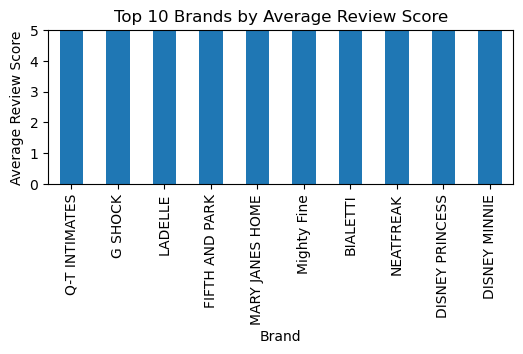

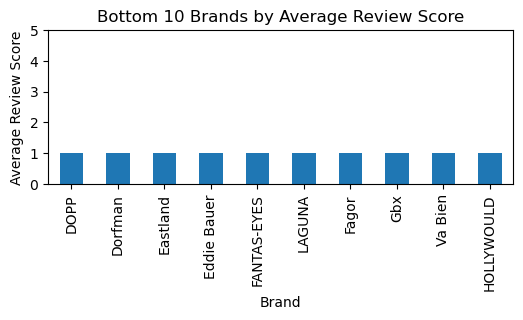

In [364]:
# Top 10 brands
top_10_brands = top_brands_by_avg_score.head(10)
ax = top_10_brands.plot(kind = 'bar', figsize=(6, 2), title= "Top 10 Brands by Average Review Score")
plt.xlabel("Brand")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)  # Set y-axis range to 0-5
plt.show()  # Set y-axis range to 0-5

# Bottom 10 brands
bottom_10_brands = top_brands_by_avg_score.tail(10)
ax = bottom_10_brands.plot(kind = 'bar', figsize=(6, 2), title = "Bottom 10 Brands by Average Review Score")
plt.xlabel("Brand")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)  # Set y-axis range to 0-5
plt.show()

<br>

- Checking brand score distribution using histograms

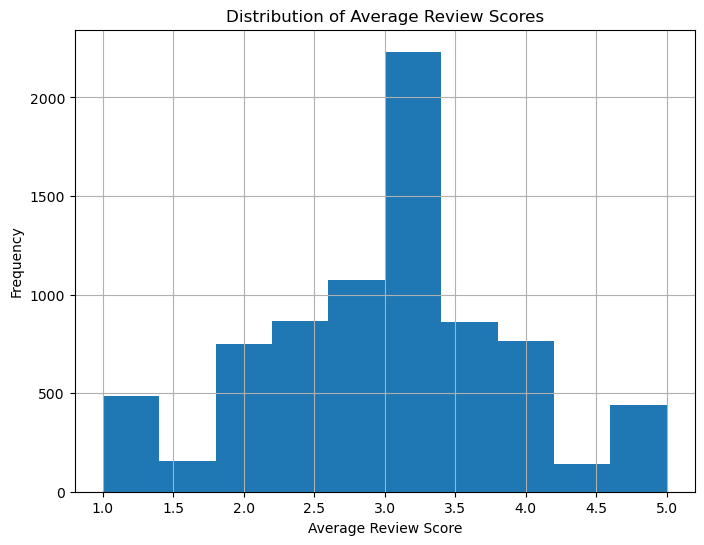

In [376]:
cleaned_products['av_score'].hist(bins=10, figsize=(8, 6))
plt.title("Distribution of Average Review Scores")
plt.xlabel("Average Review Score")
plt.ylabel("Frequency")
plt.show()

###### Central Tendancy
- The histogram represents the distribution of average review scores across brands
- A large portion of review scores are between 2.5 and 3.5 with the majority at 3
- This indicates that most brands have moderately positive reviews

###### Skewness
- The distribution almost symmetrical in shape, close to being a bell curve but brands with high average scores of 1 to 1.5 and 4.5 to 5 skew the shape
- This also shows that there is some variability in brand performance

###### Extreme scores
- This histogram suggests that poorly rated and highly rated brands are less common than moderately rated brands

###### Mode
- The most common average review score is 3, as over 2000 brands are in this range

<br> 

- Exploring user activity and average score
- Does a user who submits more reviews more critical or more positive?

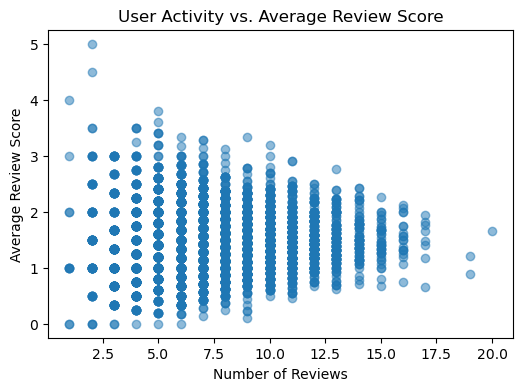

Correlation Coefficient: 0.01
P-value: 0.39150


In [414]:
# Number of reviews per user
user_review_counts = reviews_data['username'].value_counts()

# Creating a dataframe that merges user review counts and average review score
user_avg_scores = reviews_data.groupby('username')['score'].mean()
user_data = pd.DataFrame({'review_count': user_review_counts, 'avg_score': user_avg_scores})

# Scatter plot: Review count vs. average score
plt.figure(figsize=(6, 4))
plt.scatter(user_data['review_count'], user_data['avg_score'], alpha=0.5)
plt.title('User Activity vs. Average Review Score')
plt.xlabel('Number of Reviews')
plt.ylabel('Average Review Score')
plt.show()

# Pearson correlation coefficient
correlation, p_value = pearsonr(user_data['review_count'], user_data['avg_score'])
print(f"Correlation Coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.5f}")

###### Correlation Coefficient
- A pearson's coefficient of r = 0.01 indicates that there is a very weak relationship or no relationship between a number of reviews a user submits and their average review score

###### p-Value
- A p-Value of p = > 0.05 indicates that the correlation is not statistically significant
- This indicates that the observation of a weak relationship could occur by random chance

###### Distribution in scatter plot
- The data points are spread out in a horizontal manor
- There is no clear down or upward trend
- There appears to be a large variability of scores

###### Interpretation
- Users who leave many reviews are not bias, they do not give higher or lower scores compared to those who leave fewer reviews

<br>

- Investigating

<br>

- Exploring demographics

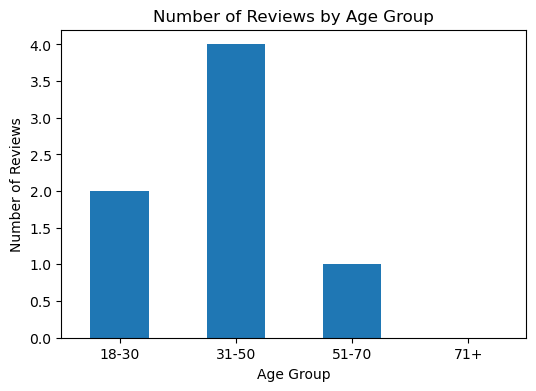

In [429]:
# Example user demographic data
users_data = pd.DataFrame({
    'username': ['user1', 'user2', 'user3', 'user4', 'user5', 'user6', 'user7'], 'age': [25, 35, 45, 60, 20, 50, 30],})

# Example reviews data
reviews_data = pd.DataFrame({'username': ['user1', 'user2', 'user3', 'user4', 'user5', 'user6', 'user2'], 
    'score': [4, 3, 5, 2, 4, 3, 5],})

# Adding age groups to `users_data`
users_data['age_group'] = pd.cut(users_data['age'], bins=[18, 30, 50, 70, 100], 
    labels=['18-30', '31-50', '51-70', '71+'])

# Merging users_data with reviews_data to include age group in reviews
user_reviews_demo = pd.merge(reviews_data, users_data, on='username')

# Counting the number of reviews per age group
age_group_review_counts = user_reviews_demo['age_group'].value_counts()

# Bar graph
plt.figure(figsize=(6, 4))
age_group_review_counts.sort_index().plot(kind='bar')
plt.title('Number of Reviews by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

- The 31 to 50 age group leaves the highest number of reviews, the 18 to 30 age group leave fewer reviews and the 51 to 70 age group leave even fewer reviews
- The 71+ age groups has left no reviews

<br>

- Age group

Average Review Score by Age Group:
age_group
18-30    4.000000
31-50    4.333333
51-70    2.500000
Name: score, dtype: float64


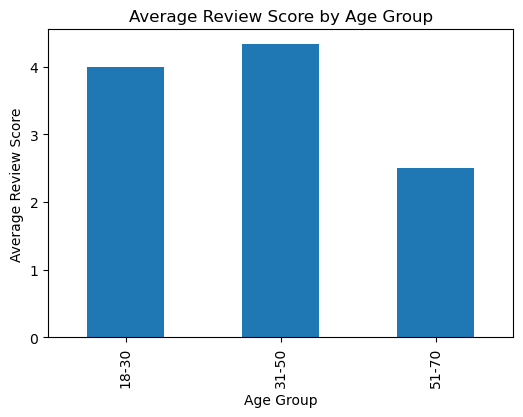

In [450]:
# Add age groups
users_data['age_group'] = pd.cut(users_data['age'], bins=[18, 30, 45, 60, 100], labels=['18-30', '31-50', '51-70', '71+'])


# Merge user data with reviews
user_reviews_demo = pd.merge(reviews_data, users_data, on='username')

# Average review score by age group
age_group_scores = user_reviews_demo.groupby('age_group', observed=True)['score'].mean()
print("Average Review Score by Age Group:")
print(age_group_scores)

# Bar chart
age_group_scores.plot(kind='bar', figsize=(6, 4), title="Average Review Score by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Review Score")
plt.show()

- The 31-50 age group leaves the highes scoring reviews with an average of 4.33
- The 18-30 age group leaves the second highest scoring reviews with an average of 4
- The 51-70 age group leaves the lowest score of reviews with an average of 2.5

<br>

F-statistic: nan
P-value: nan
There is no statistically significant difference in review scores between the age groups.


C:\Users\nnico\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


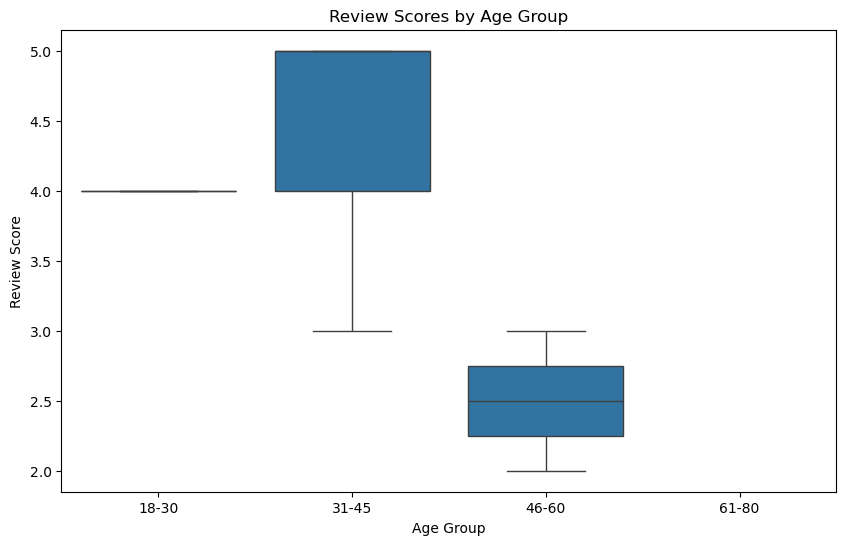

In [490]:
# Section 1: Boxplot of Review Scores by Age Group

# Perform one-way ANOVA to ensure there's a reason for comparison
group_18_30 = user_reviews_demo[user_reviews_demo['age_group'] == '18-30']['score']
group_31_50 = user_reviews_demo[user_reviews_demo['age_group'] == '31-50']['score']
group_51_70 = user_reviews_demo[user_reviews_demo['age_group'] == '51-70']['score']

# Perform ANOVA
f_stat, p_value = f_oneway(group_18_30, group_31_50, group_51_70)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("There is a statistically significant difference in review scores between the age groups.")
else:
    print("There is no statistically significant difference in review scores between the age groups.")

# Boxplot Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='score', data=user_reviews_demo)
plt.title('Review Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Review Score')
plt.show()

# Add comments explaining boxplot:
# 1. Boxplot shows the distribution of review scores for each age group.
# 2. Median values, quartiles, and potential outliers can be easily observed.
# 3. Look for differences in the distribution of scores between age groups.

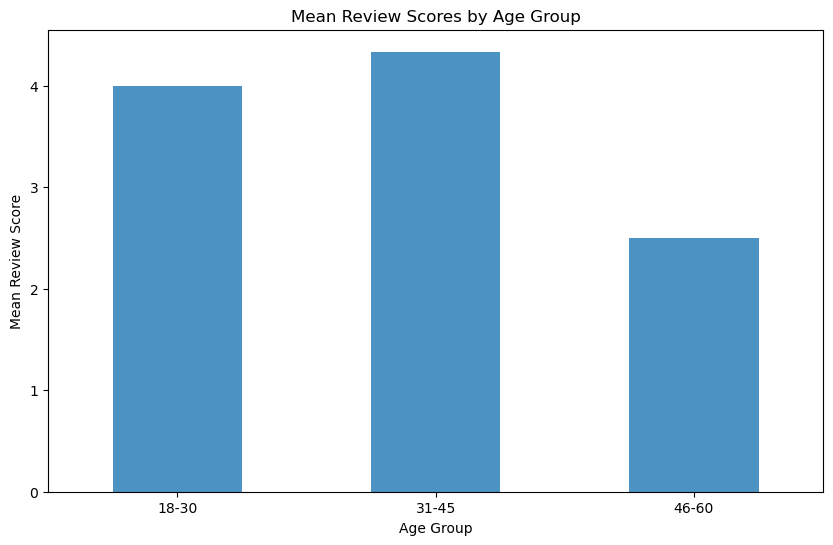

In [488]:
# Section 2: Bar Chart of Mean Review Scores by Age Group

# Calculate mean scores for each age group
mean_scores = user_reviews_demo.groupby('age_group', observed=True)['score'].mean()

# Bar Chart Visualization
plt.figure(figsize=(10, 6))
mean_scores.plot(kind='bar', alpha=0.8)
plt.title('Mean Review Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mean Review Score')
plt.xticks(rotation=0)
plt.show()

# Add comments explaining bar chart:
# 1. Bar chart provides a quick overview of average review scores for each age group.
# 2. This visualization is useful for comparing the mean scores directly.
# 3. Look for patterns, such as which age group leaves higher or lower average scores.